# Лабораторная работа №2
## Промышленный пайплайн обучения нейросети в PyTorch с мониторингом в TensorBoard

**Датасет:** Fashion-MNIST — бинарная классификация **Футболка (T-shirt/top) vs Ботинок (Ankle boot)**

**Задачи:**
1. Создание конвейера обработки данных с использованием `torchvision.transforms`
2. Реализация кастомного DataLoader с аугментацией
3. Построение модульной архитектуры CNN
4. Реализация класса Trainer с поддержкой checkpointing
5. Интеграция TensorBoard в пайплайн обучения
6. Визуализация кривых обучения и метрик валидации
7. Отслеживание распределения градиентов и весов
8. Создание дашборда для сравнения различных моделей
9. Выводы

## Подготовка окружения

In [1]:
# Установка зависимостей
!pip install torch torchvision tensorboard matplotlib seaborn scikit-learn tqdm

In [2]:
import os
import random
import warnings
import json
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import torchvision.transforms as T
from torchvision.datasets import FashionMNIST

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Импорт завершён')

Импорт завершён


In [3]:
# ─── Гиперпараметры и конфигурация ───
SEED        = 42
IMG_SIZE    = 64
BATCH_SIZE  = 64
NUM_WORKERS = 2
LR          = 1e-3
EPOCHS      = 15
NUM_CLASSES = 2

# Индексы классов Fashion-MNIST
CLS_TSHIRT = 0   # T-shirt/top
CLS_BOOT   = 9   # Ankle boot
CLASS_NAMES = ['Футболка', 'Ботинок']

CKPT_DIR = Path('checkpoints'); CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR  = Path('runs');        LOG_DIR.mkdir(exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Устройство: cuda
GPU: Tesla T4


## Загрузка и разведочный анализ данных (EDA)

Fashion-MNIST содержит 70 000 изображений одежды 28×28 в оттенках серого, разделённых на 10 классов.
Для бинарной задачи отбираем два класса:
- **Класс 0 — T-shirt/top** (Футболка)
- **Класс 9 — Ankle boot** (Ботинок)

In [4]:
# Загрузка Fashion-MNIST
raw_train = FashionMNIST(root='./data', train=True,  download=True)
raw_test  = FashionMNIST(root='./data', train=False, download=True)

# Фильтрация: оставляем только T-shirt (0) и Ankle boot (9)
train_mask = (raw_train.targets == CLS_TSHIRT) | (raw_train.targets == CLS_BOOT)
test_mask  = (raw_test.targets  == CLS_TSHIRT) | (raw_test.targets  == CLS_BOOT)

train_images = raw_train.data[train_mask].numpy()
train_labels = raw_train.targets[train_mask].numpy()
test_images  = raw_test.data[test_mask].numpy()
test_labels  = raw_test.targets[test_mask].numpy()

# Ремаппинг: T-shirt → 0, Boot → 1
train_labels = (train_labels == CLS_BOOT).astype(np.int64)
test_labels  = (test_labels  == CLS_BOOT).astype(np.int64)

print(f'Тренировочная выборка: {len(train_images)} изображений')
print(f'Тестовая выборка:      {len(test_images)} изображений')
print(f'Размер изображения:    {train_images[0].shape}')
print(f'\nРаспределение классов (train):')
for i, name in enumerate(CLASS_NAMES):
    cnt = (train_labels == i).sum()
    print(f'  {name}: {cnt} ({cnt/len(train_labels)*100:.1f}%)')

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.4MB/s]

Тренировочная выборка: 12000 изображений
Тестовая выборка:      2000 изображений
Размер изображения:    (28, 28)

Распределение классов (train):
  Футболка: 6000 (50.0%)
  Ботинок: 6000 (50.0%)


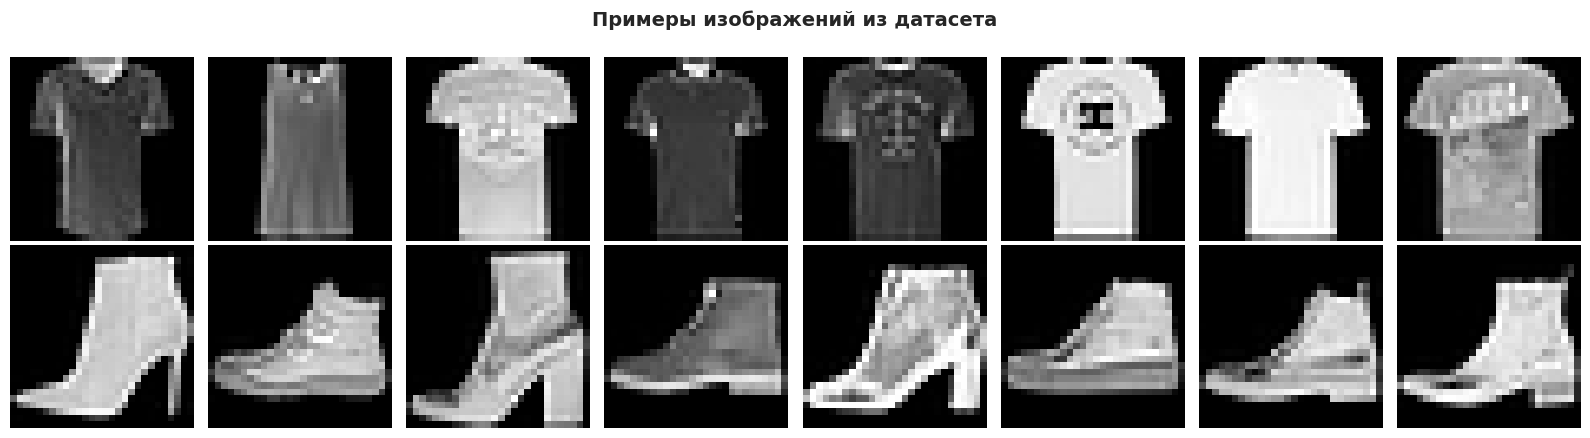

In [5]:
# Визуализация случайных примеров
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
fig.suptitle('Примеры изображений из датасета', fontsize=14, fontweight='bold')

for row, cls in enumerate([0, 1]):
    indices = np.where(train_labels == cls)[0]
    samples = np.random.choice(indices, 8, replace=False)
    for col, idx in enumerate(samples):
        axes[row, col].imshow(train_images[idx], cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(CLASS_NAMES[cls], fontsize=12, fontweight='bold')
            axes[row, col].yaxis.set_visible(True)
            axes[row, col].set_yticks([])

plt.tight_layout()
plt.show()

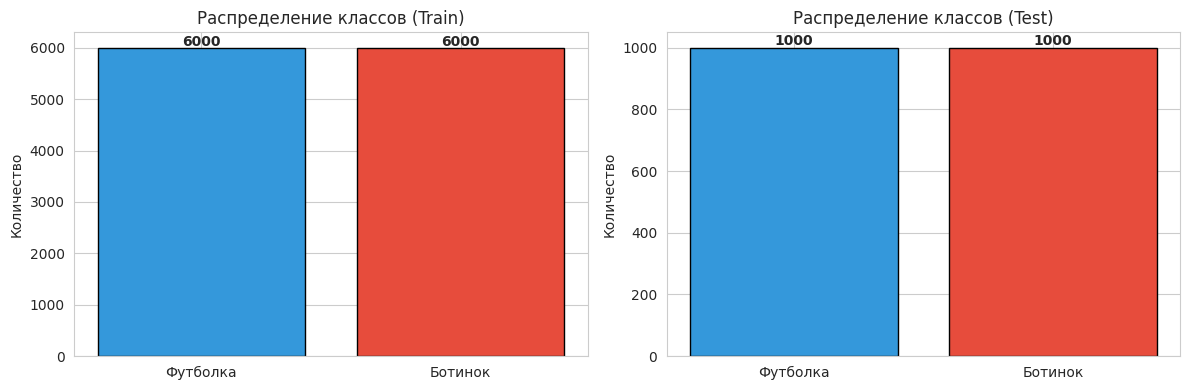

Баланс train: 1.00 : 1
Баланс test:  1.00 : 1


In [6]:
# Распределение классов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Train
counts_train = [(train_labels == i).sum() for i in range(NUM_CLASSES)]
ax1.bar(CLASS_NAMES, counts_train, color=['#3498db', '#e74c3c'], edgecolor='black')
ax1.set_title('Распределение классов (Train)')
ax1.set_ylabel('Количество')
for i, v in enumerate(counts_train):
    ax1.text(i, v + 30, str(v), ha='center', fontweight='bold')

# Test
counts_test = [(test_labels == i).sum() for i in range(NUM_CLASSES)]
ax2.bar(CLASS_NAMES, counts_test, color=['#3498db', '#e74c3c'], edgecolor='black')
ax2.set_title('Распределение классов (Test)')
ax2.set_ylabel('Количество')
for i, v in enumerate(counts_test):
    ax2.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Баланс train: {counts_train[0]/counts_train[1]:.2f} : 1')
print(f'Баланс test:  {counts_test[0]/counts_test[1]:.2f} : 1')

## Задание 1. Конвейер предобработки изображений (`torchvision.transforms`)

Создаём два конвейера преобразований:
- **Тренировочный** — с аугментацией (flip, rotation, affine, jitter, blur) для регуляризации и расширения выборки
- **Валидационный** — только resize и нормализация для воспроизводимости оценки

Нормализация выполняется со средним 0.5 и стандартным отклонением 0.5, приводя пиксели к диапазону [-1, 1].

In [7]:
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=12),
    T.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

print('Тренировочный конвейер:')
for i, t in enumerate(train_transform.transforms):
    print(f'  {i+1}. {t}')
print(f'\nВалидационный конвейер:')
for i, t in enumerate(val_transform.transforms):
    print(f'  {i+1}. {t}')

Тренировочный конвейер:
  1. Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
  2. RandomHorizontalFlip(p=0.5)
  3. RandomRotation(degrees=[-12.0, 12.0], interpolation=nearest, expand=False, fill=0)
  4. RandomAffine(degrees=[0.0, 0.0], translate=(0.08, 0.08), scale=(0.9, 1.1))
  5. ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=None, hue=None)
  6. GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.5))
  7. ToTensor()
  8. Normalize(mean=[0.5], std=[0.5])

Валидационный конвейер:
  1. Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
  2. ToTensor()
  3. Normalize(mean=[0.5], std=[0.5])


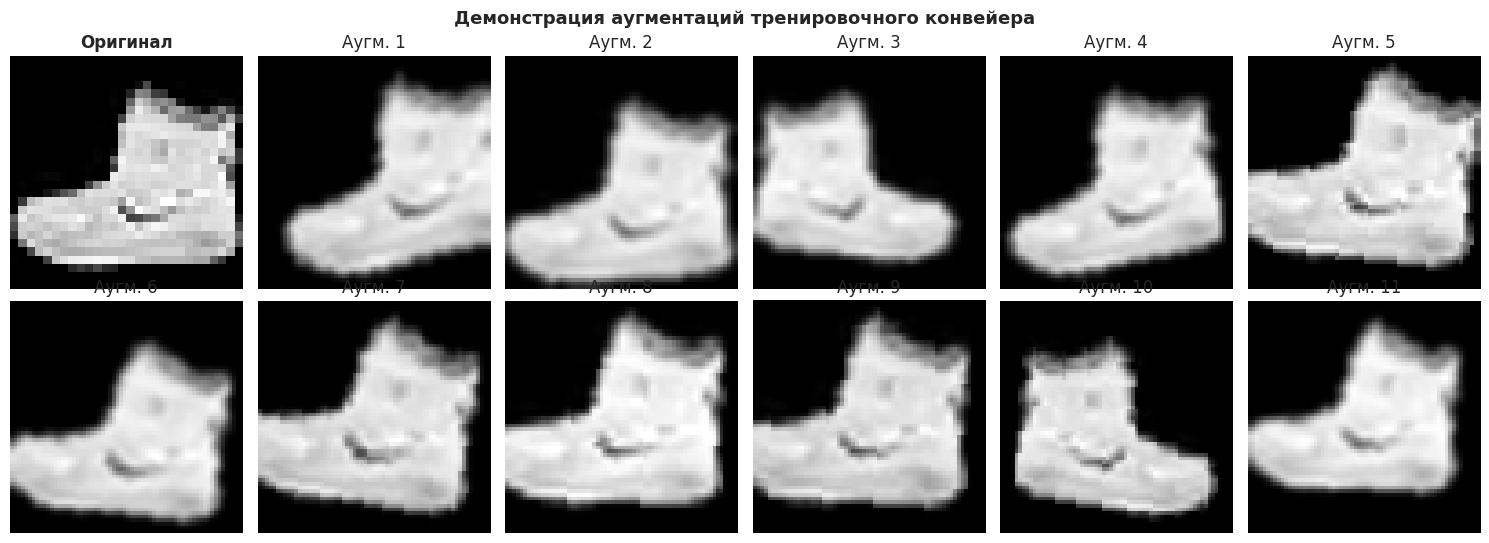

In [8]:
# Демонстрация аугментаций на одном изображении
sample_img = Image.fromarray(train_images[0], mode='L')

fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
fig.suptitle('Демонстрация аугментаций тренировочного конвейера', fontsize=13, fontweight='bold')

axes[0, 0].imshow(train_images[0], cmap='gray')
axes[0, 0].set_title('Оригинал', fontweight='bold')
axes[0, 0].axis('off')

for i in range(1, 12):
    r, c = divmod(i, 6)
    augmented = train_transform(sample_img)
    # Денормализация для визуализации
    img_vis = augmented.squeeze().numpy() * 0.5 + 0.5
    axes[r, c].imshow(img_vis, cmap='gray')
    axes[r, c].set_title(f'Аугм. {i}')
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

## Задание 2. Кастомный DataLoader с аугментацией

Класс `FashionBinaryDataset` наследует `torch.utils.data.Dataset` и обеспечивает:
- Чтение grayscale-изображений из numpy-массива
- Применение цепочки аугментаций через `transform`
- Возврат тензоров `(image, label)` для батчирования

In [9]:
class FashionBinaryDataset(Dataset):
    """Кастомный Dataset для бинарной классификации Fashion-MNIST."""

    def __init__(self, images: np.ndarray, labels: np.ndarray, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx], mode='L')
        label = int(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
# Разбиение train на train/val (85% / 15%) с сохранением баланса
tr_imgs, val_imgs, tr_lbls, val_lbls = train_test_split(
    train_images, train_labels,
    test_size=0.15, random_state=SEED, stratify=train_labels
)

train_ds = FashionBinaryDataset(tr_imgs,  tr_lbls,  transform=train_transform)
val_ds   = FashionBinaryDataset(val_imgs, val_lbls, transform=val_transform)
test_ds  = FashionBinaryDataset(test_images, test_labels, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_ds):>5} изображений  ({len(train_loader)} батчей)')
print(f'Val:   {len(val_ds):>5} изображений  ({len(val_loader)} батчей)')
print(f'Test:  {len(test_ds):>5} изображений  ({len(test_loader)} батчей)')

# Проверка формы батча
imgs, lbls = next(iter(train_loader))
print(f'\nФорма батча images: {imgs.shape}')
print(f'Форма батча labels: {lbls.shape}')
print(f'Диапазон значений:  [{imgs.min():.2f}, {imgs.max():.2f}]')

Train: 10200 изображений  (160 батчей)
Val:    1800 изображений  (29 батчей)
Test:   2000 изображений  (32 батчей)

Форма батча images: torch.Size([64, 1, 64, 64])
Форма батча labels: torch.Size([64])
Диапазон значений:  [-1.00, 1.00]


## Задание 3. Модульная архитектура CNN

Строим набор переиспользуемых блоков и три архитектуры с растущей сложностью:

| Модель | Описание | Ключевые блоки |
|---|---|---|
| `FashionNet_Small` | Лёгкая: 3 свёрточных слоя | ConvBlock |
| `FashionNet_Medium` | Средняя: 4 слоя + residual | ConvBlock + ResidualBlock |
| `FashionNet_Large` | Тяжёлая: 5 слоёв + residual + SE-attention | ConvBlock + ResidualBlock + SEBlock |

In [11]:
# ─── Базовые блоки ───

class ConvBlock(nn.Module):
    """Свёрточный блок: Conv2d -> BatchNorm -> ReLU -> [MaxPool2d]"""
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class ResidualBlock(nn.Module):
    """Остаточный блок: две свёртки 3x3 со skip-connection"""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + x)


class SEBlock(nn.Module):
    """Squeeze-and-Excitation: адаптивное перевзвешивание каналов"""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w


print('Базовые блоки определены: ConvBlock, ResidualBlock, SEBlock')

Базовые блоки определены: ConvBlock, ResidualBlock, SEBlock


In [12]:
# ─── Архитектуры моделей ───

class FashionNet_Small(nn.Module):
    """Лёгкая модель: 3 свёрточных блока, ~95K параметров"""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32),    # 64 -> 32
            ConvBlock(32, 64),   # 32 -> 16
            ConvBlock(64, 128),  # 16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class FashionNet_Medium(nn.Module):
    """Средняя модель: 4 свёрточных блока + residual, ~560K параметров"""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32),       # 64 -> 32
            ResidualBlock(32),
            ConvBlock(32, 64),      # 32 -> 16
            ResidualBlock(64),
            ConvBlock(64, 128),     # 16 -> 8
            ConvBlock(128, 256),    # 8  -> 4
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class FashionNet_Large(nn.Module):
    """Тяжёлая модель: 5 блоков + residual + SE-attention, ~2.1M параметров"""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32),       # 64 -> 32
            ResidualBlock(32),
            SEBlock(32),
            ConvBlock(32, 64),      # 32 -> 16
            ResidualBlock(64),
            SEBlock(64),
            ConvBlock(64, 128),     # 16 -> 8
            ResidualBlock(128),
            ConvBlock(128, 256),    # 8  -> 4
            ConvBlock(256, 512),    # 4  -> 2
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Словарь моделей
MODELS = {
    'FashionNet_Small':  FashionNet_Small,
    'FashionNet_Medium': FashionNet_Medium,
    'FashionNet_Large':  FashionNet_Large,
}

In [13]:
# Сводка по архитектурам
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'{"Модель":<22} {"Параметры":>12}')
print('─' * 36)
for name, cls in MODELS.items():
    m = cls()
    print(f'{name:<22} {count_params(m):>12,}')

# Проверка forward pass
dummy = torch.randn(2, 1, IMG_SIZE, IMG_SIZE)
for name, cls in MODELS.items():
    m = cls()
    out = m(dummy)
    assert out.shape == (2, NUM_CLASSES), f'{name}: unexpected output shape {out.shape}'
print('\nForward pass проверен для всех моделей ✓')

Модель                    Параметры
────────────────────────────────────
FashionNet_Small            101,506
FashionNet_Medium           514,690
FashionNet_Large          2,108,866

Forward pass проверен для всех моделей ✓


## Задания 4, 5, 7. Класс Trainer с checkpointing, TensorBoard и мониторингом градиентов

Класс `Trainer` объединяет:
- **Задание 4**: сохранение/загрузка чекпоинтов (best + last), early stopping
- **Задание 5**: запись скаляров, гистограмм и графа модели в TensorBoard
- **Задание 7**: логирование распределений весов и градиентов каждые N эпох

Используется `CrossEntropyLoss` для бинарной классификации, оптимизатор `Adam` с weight decay
и `CosineAnnealingLR` scheduler для плавного уменьшения learning rate.

In [14]:
class Trainer:
    """Класс обучения с checkpointing, TensorBoard и мониторингом градиентов."""

    def __init__(self, model, train_loader, val_loader, criterion, optimizer,
                 scheduler=None, device='cpu', name='model'):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.name = name

        # TensorBoard writer
        self.log_dir = LOG_DIR / name
        self.writer = SummaryWriter(log_dir=str(self.log_dir))

        # Запись графа модели
        dummy = torch.randn(1, 1, IMG_SIZE, IMG_SIZE).to(device)
        self.writer.add_graph(model, dummy)

        self.best_val_acc = 0.0
        self.patience_counter = 0
        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss': [],   'val_acc': [],
            'lr': [],
        }

    # ── Одна тренировочная эпоха ──
    def _train_epoch(self):
        self.model.train()
        total_loss, correct, total = 0.0, 0, 0

        for images, labels in self.train_loader:
            images = images.to(self.device)
            labels = labels.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        return total_loss / total, correct / total

    # ── Одна валидационная эпоха ──
    @torch.no_grad()
    def _val_epoch(self):
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0

        for images, labels in self.val_loader:
            images = images.to(self.device)
            labels = labels.to(self.device)

            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        return total_loss / total, correct / total

    # ── Логирование гистограмм весов и градиентов (задание 7) ──
    def _log_histograms(self, epoch):
        for tag, param in self.model.named_parameters():
            if param.requires_grad:
                self.writer.add_histogram(f'weights/{tag}', param.data, epoch)
                if param.grad is not None:
                    self.writer.add_histogram(f'gradients/{tag}', param.grad, epoch)

    # ── Сохранение чекпоинта (задание 4) ──
    def save_checkpoint(self, epoch, is_best=False):
        state = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_val_acc': self.best_val_acc,
            'history': self.history,
        }
        ckpt_path = CKPT_DIR / self.name
        ckpt_path.mkdir(exist_ok=True)
        torch.save(state, ckpt_path / f'{self.name}_last.pth')
        if is_best:
            torch.save(state, ckpt_path / f'{self.name}_best.pth')

    # ── Загрузка чекпоинта ──
    def load_checkpoint(self, best=True):
        tag = 'best' if best else 'last'
        path = CKPT_DIR / self.name / f'{self.name}_{tag}.pth'
        ckpt = torch.load(path, map_location=self.device, weights_only=False)
        self.model.load_state_dict(ckpt['model_state_dict'])
        return ckpt

    # ── Основной цикл обучения ──
    def fit(self, epochs, patience=8):
        for epoch in range(1, epochs + 1):
            train_loss, train_acc = self._train_epoch()
            val_loss, val_acc = self._val_epoch()

            lr = self.optimizer.param_groups[0]['lr']
            if self.scheduler:
                self.scheduler.step()

            # Сохраняем историю
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['lr'].append(lr)

            # TensorBoard: скаляры (задание 5)
            self.writer.add_scalars(f'{self.name}/Loss',
                {'train': train_loss, 'val': val_loss}, epoch)
            self.writer.add_scalars(f'{self.name}/Accuracy',
                {'train': train_acc, 'val': val_acc}, epoch)
            self.writer.add_scalar(f'{self.name}/LearningRate', lr, epoch)

            # TensorBoard: гистограммы каждые 3 эпохи (задание 7)
            if epoch % 3 == 0 or epoch == 1:
                self._log_histograms(epoch)

            # Checkpointing (задание 4)
            is_best = val_acc > self.best_val_acc
            if is_best:
                self.best_val_acc = val_acc
                self.patience_counter = 0
            else:
                self.patience_counter += 1

            self.save_checkpoint(epoch, is_best)

            marker = ' ★ best' if is_best else ''
            print(f'  Epoch {epoch:2d}/{epochs} │ '
                  f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} │ '
                  f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} │ '
                  f'LR: {lr:.6f}{marker}')

            # Early stopping
            if self.patience_counter >= patience:
                print(f'  ✗ Early stopping (patience={patience})')
                break

        self.writer.close()
        print(f'  Лучшая Val Accuracy: {self.best_val_acc:.4f}')
        return self.history

## Обучение трёх моделей

In [15]:
def create_trainer(model_cls, name):
    """Фабрика: создаёт модель, оптимизатор, scheduler и Trainer."""
    set_seed()
    model = model_cls()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    return Trainer(
        model=model, train_loader=train_loader, val_loader=val_loader,
        criterion=criterion, optimizer=optimizer, scheduler=scheduler,
        device=device, name=name,
    )

trainers  = {}
histories = {}

for name, cls in MODELS.items():
    print(f'\n{"═" * 70}')
    print(f' Обучение: {name}')
    print(f'{"═" * 70}')
    trainer = create_trainer(cls, name)
    history = trainer.fit(EPOCHS, patience=10)
    trainers[name]  = trainer
    histories[name] = history


══════════════════════════════════════════════════════════════════════
 Обучение: FashionNet_Small
══════════════════════════════════════════════════════════════════════
  Epoch  1/15 │ Train Loss: 0.1712  Acc: 0.9428 │ Val Loss: 0.2944  Acc: 0.8983 │ LR: 0.001000 ★ best
  Epoch  2/15 │ Train Loss: 0.0669  Acc: 0.9786 │ Val Loss: 0.0234  Acc: 0.9933 │ LR: 0.000989 ★ best
  Epoch  3/15 │ Train Loss: 0.0483  Acc: 0.9860 │ Val Loss: 0.0511  Acc: 0.9856 │ LR: 0.000957
  Epoch  4/15 │ Train Loss: 0.0332  Acc: 0.9901 │ Val Loss: 0.0240  Acc: 0.9928 │ LR: 0.000905
  Epoch  5/15 │ Train Loss: 0.0277  Acc: 0.9915 │ Val Loss: 0.0168  Acc: 0.9944 │ LR: 0.000835 ★ best
  Epoch  6/15 │ Train Loss: 0.0219  Acc: 0.9927 │ Val Loss: 0.0273  Acc: 0.9922 │ LR: 0.000750
  Epoch  7/15 │ Train Loss: 0.0221  Acc: 0.9929 │ Val Loss: 0.1072  Acc: 0.9572 │ LR: 0.000655
  Epoch  8/15 │ Train Loss: 0.0197  Acc: 0.9946 │ Val Loss: 0.0139  Acc: 0.9967 │ LR: 0.000552 ★ best
  Epoch  9/15 │ Train Loss: 0.0139  Acc: 

## Задание 5 (продолжение). Запуск TensorBoard

TensorBoard интегрирован в класс `Trainer`:
- Граф модели (`add_graph`)
- Скаляры Loss, Accuracy, LearningRate (`add_scalars`, `add_scalar`)
- Гистограммы весов и градиентов (`add_histogram`)

Раскомментируйте ячейку ниже для интерактивного просмотра, либо запустите в терминале:
```
tensorboard --logdir runs
```

In [16]:
%load_ext tensorboard
%tensorboard --logdir runs

<IPython.core.display.Javascript object>

## Задание 6. Визуализация кривых обучения и метрик валидации

Построим графики Loss, Accuracy и Learning Rate для всех трёх моделей,
а также матрицы ошибок на валидационной выборке.

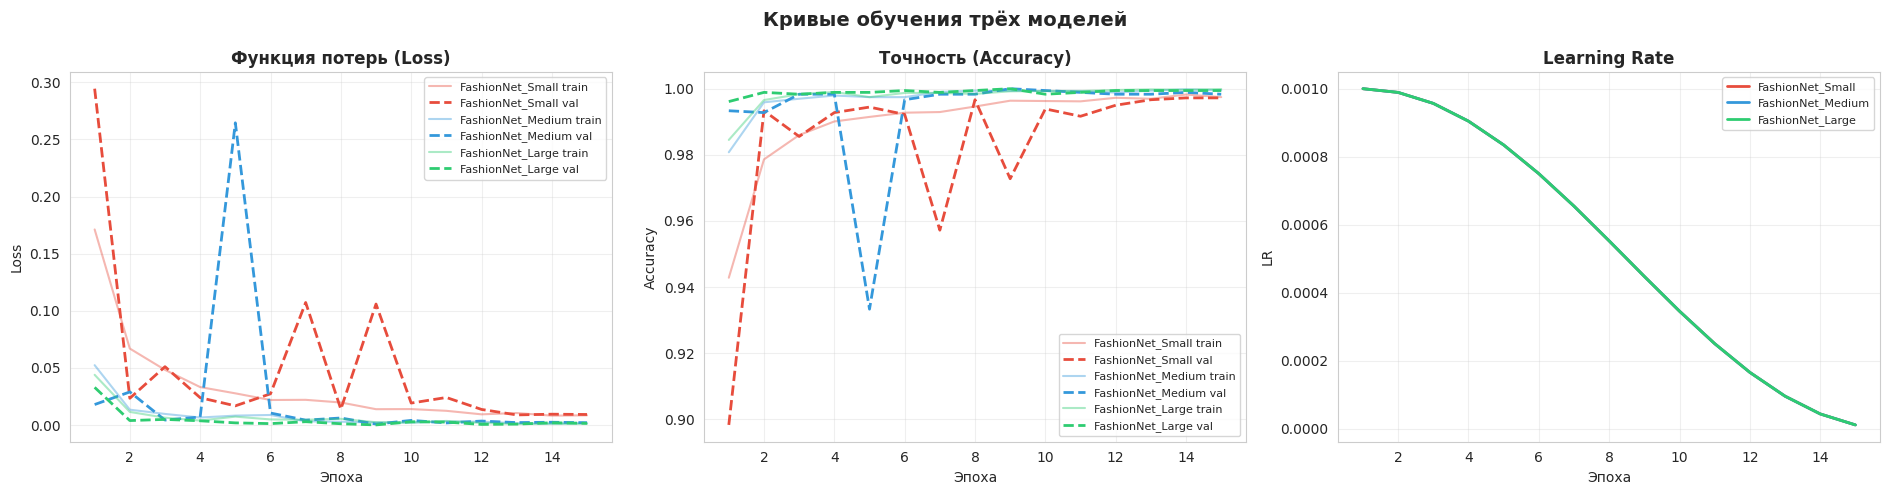

In [17]:
COLORS = {
    'FashionNet_Small':  '#e74c3c',
    'FashionNet_Medium': '#3498db',
    'FashionNet_Large':  '#2ecc71',
}

def plot_training_curves(histories):
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    titles = ['Функция потерь (Loss)', 'Точность (Accuracy)', 'Learning Rate']

    for name, h in histories.items():
        c = COLORS[name]
        ep = range(1, len(h['train_loss']) + 1)

        axes[0].plot(ep, h['train_loss'], '-',  color=c, alpha=0.4, label=f'{name} train')
        axes[0].plot(ep, h['val_loss'],   '--', color=c, linewidth=2, label=f'{name} val')

        axes[1].plot(ep, h['train_acc'], '-',  color=c, alpha=0.4, label=f'{name} train')
        axes[1].plot(ep, h['val_acc'],   '--', color=c, linewidth=2, label=f'{name} val')

        axes[2].plot(ep, h['lr'], '-', color=c, linewidth=2, label=name)

    for i, title in enumerate(titles):
        axes[i].set_title(title, fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Эпоха')
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)

    axes[0].set_ylabel('Loss')
    axes[1].set_ylabel('Accuracy')
    axes[2].set_ylabel('LR')

    plt.suptitle('Кривые обучения трёх моделей', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_curves(histories)

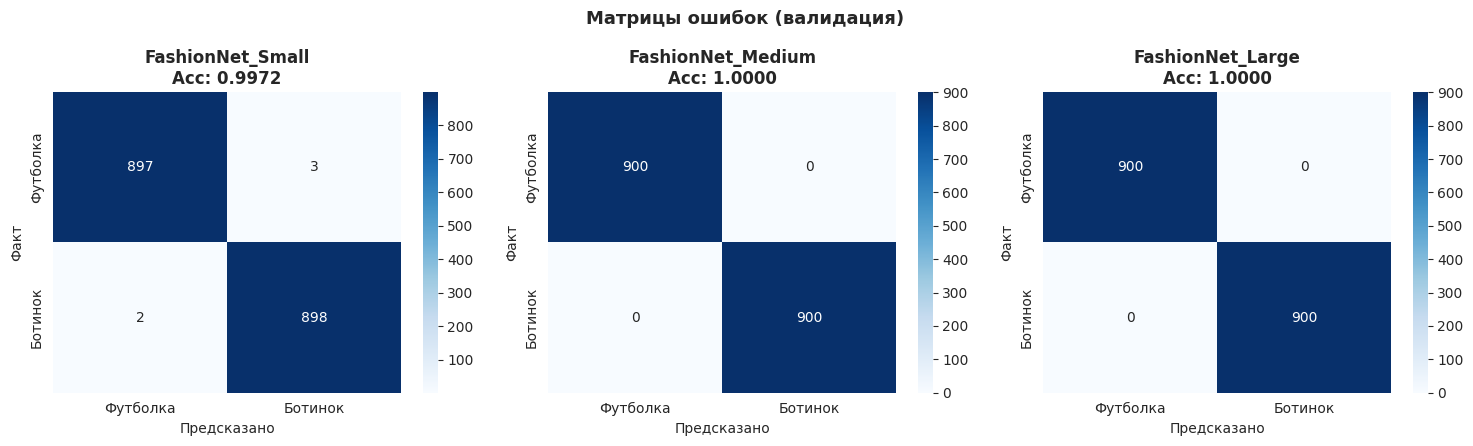

In [18]:
def plot_confusion_matrices(trainers):
    fig, axes = plt.subplots(1, len(trainers), figsize=(5 * len(trainers), 4.5))

    for ax, (name, tr) in zip(axes, trainers.items()):
        tr.load_checkpoint(best=True)
        tr.model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                outputs = tr.model(images)
                _, preds = outputs.max(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        cm = confusion_matrix(all_labels, all_preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        acc = np.trace(cm) / cm.sum()
        ax.set_title(f'{name}\nAcc: {acc:.4f}', fontweight='bold')
        ax.set_xlabel('Предсказано')
        ax.set_ylabel('Факт')

    plt.suptitle('Матрицы ошибок (валидация)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(trainers)

In [19]:
# Classification report для лучшей модели
best_model_name = max(histories, key=lambda n: max(histories[n]['val_acc']))
print(f'Лучшая модель: {best_model_name}\n')

tr = trainers[best_model_name]
tr.load_checkpoint(best=True)
tr.model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = tr.model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Лучшая модель: FashionNet_Medium

              precision    recall  f1-score   support

    Футболка       1.00      1.00      1.00       900
     Ботинок       1.00      1.00      1.00       900

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



## Задание 7. Распределения градиентов и весов

Анализ распределений позволяет диагностировать:
- **Затухающие градиенты** — сужение распределения к нулю
- **Взрывающиеся градиенты** — появление экстремальных значений
- **Неравномерность обучения** — различие масштабов градиентов между слоями

Гистограммы весов/градиентов записаны в TensorBoard (задание 5).
Ниже — визуализация средствами matplotlib.

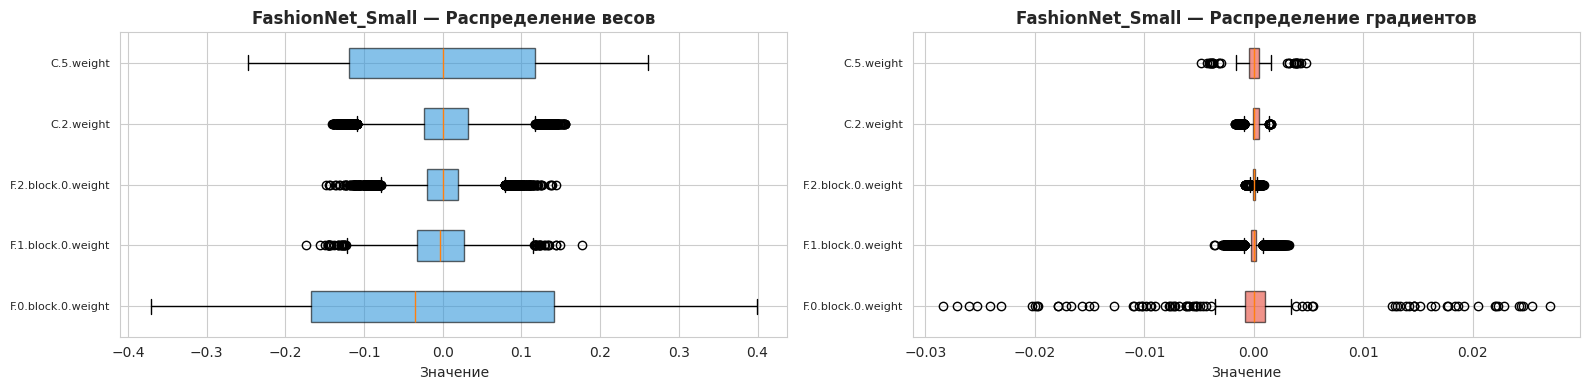

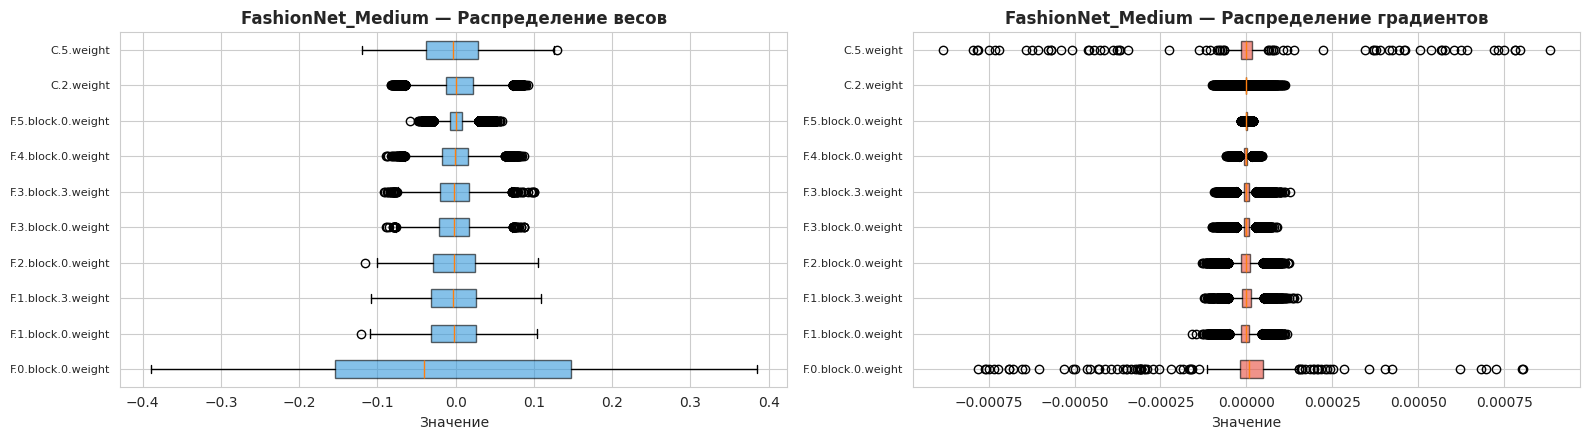

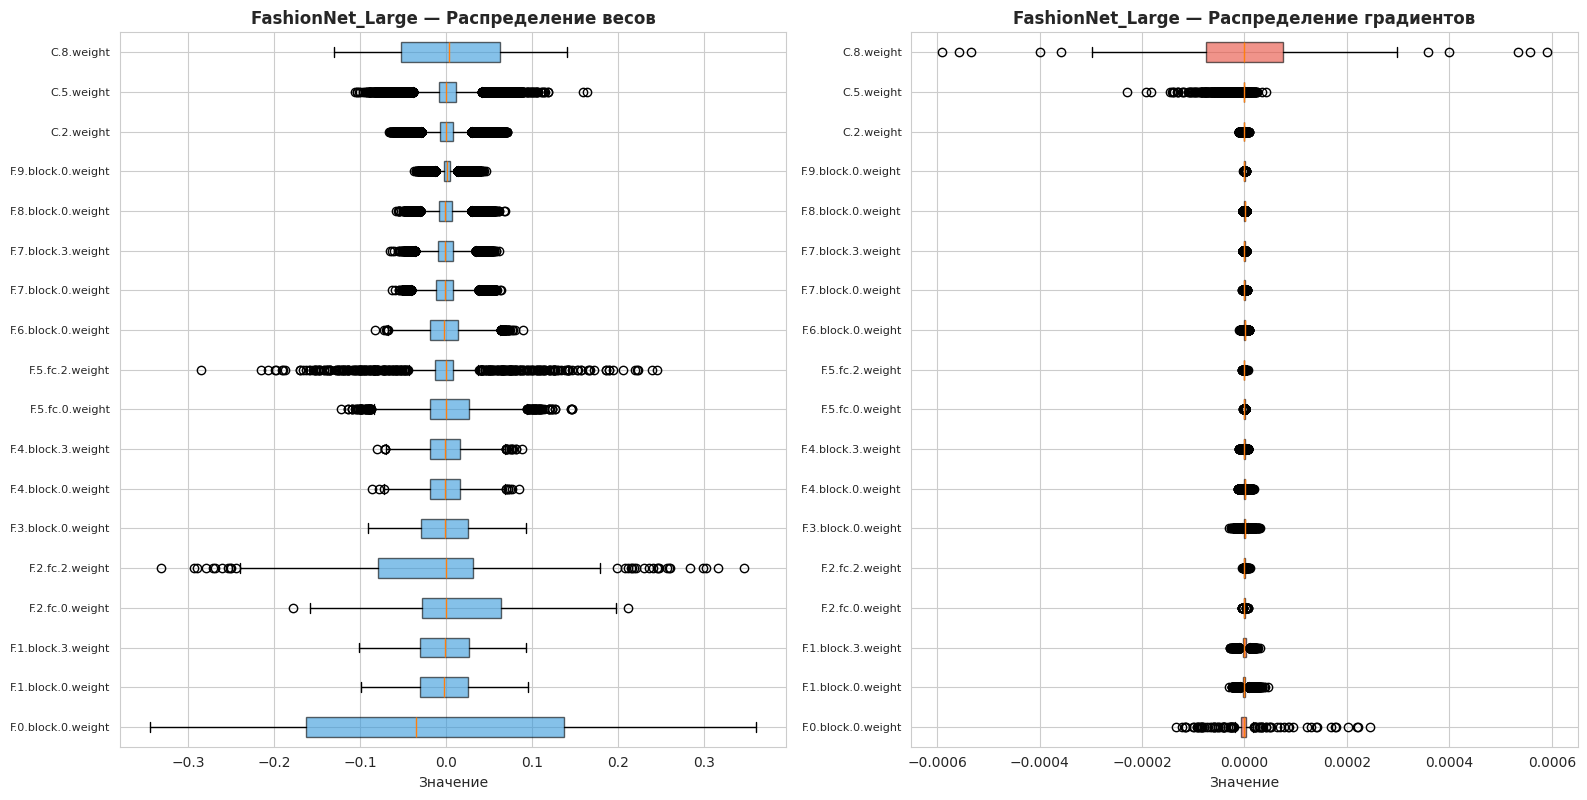

In [20]:
def plot_weight_grad_distributions(trainers):
    for name, tr in trainers.items():
        tr.load_checkpoint(best=True)
        model = tr.model
        model.train()

        # Один forward + backward для получения градиентов
        images, labels = next(iter(tr.train_loader))
        images, labels = images.to(device), labels.to(device)
        model.zero_grad()
        loss = tr.criterion(model(images), labels)
        loss.backward()

        w_data, g_data, names = [], [], []
        for n, p in model.named_parameters():
            if p.requires_grad and 'weight' in n and p.dim() >= 2:
                w_data.append(p.data.cpu().flatten().numpy())
                g_data.append(p.grad.cpu().flatten().numpy())
                short = n.replace('features.', 'F.').replace('classifier.', 'C.')
                names.append(short)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(4, len(names) * 0.45)))

        bp1 = ax1.boxplot(w_data, vert=False, patch_artist=True,
                          boxprops=dict(facecolor='#3498db', alpha=0.6))
        ax1.set_yticklabels(names, fontsize=8)
        ax1.set_title(f'{name} — Распределение весов', fontweight='bold')
        ax1.set_xlabel('Значение')

        bp2 = ax2.boxplot(g_data, vert=False, patch_artist=True,
                          boxprops=dict(facecolor='#e74c3c', alpha=0.6))
        ax2.set_yticklabels(names, fontsize=8)
        ax2.set_title(f'{name} — Распределение градиентов', fontweight='bold')
        ax2.set_xlabel('Значение')

        plt.tight_layout()
        plt.show()

plot_weight_grad_distributions(trainers)

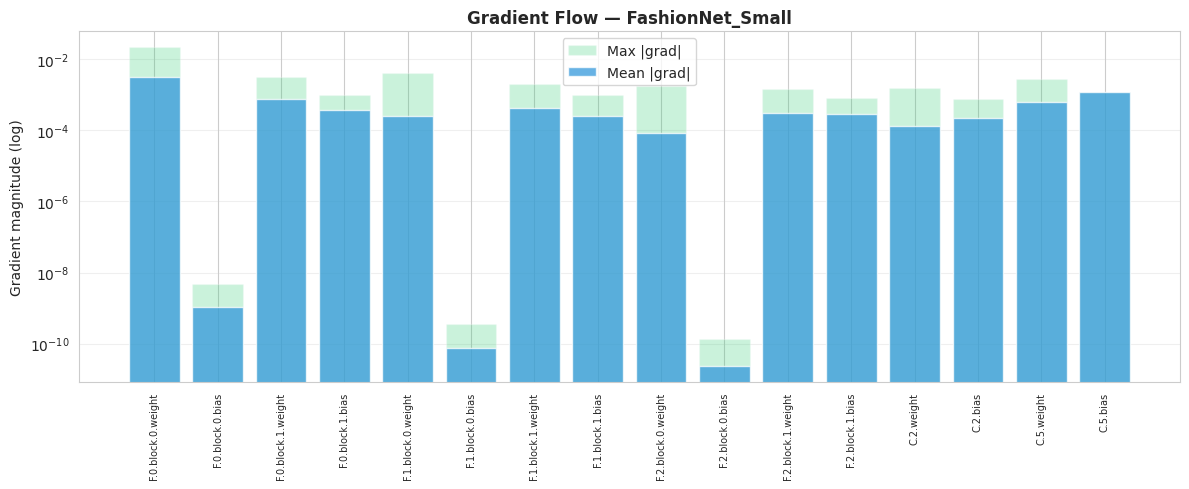

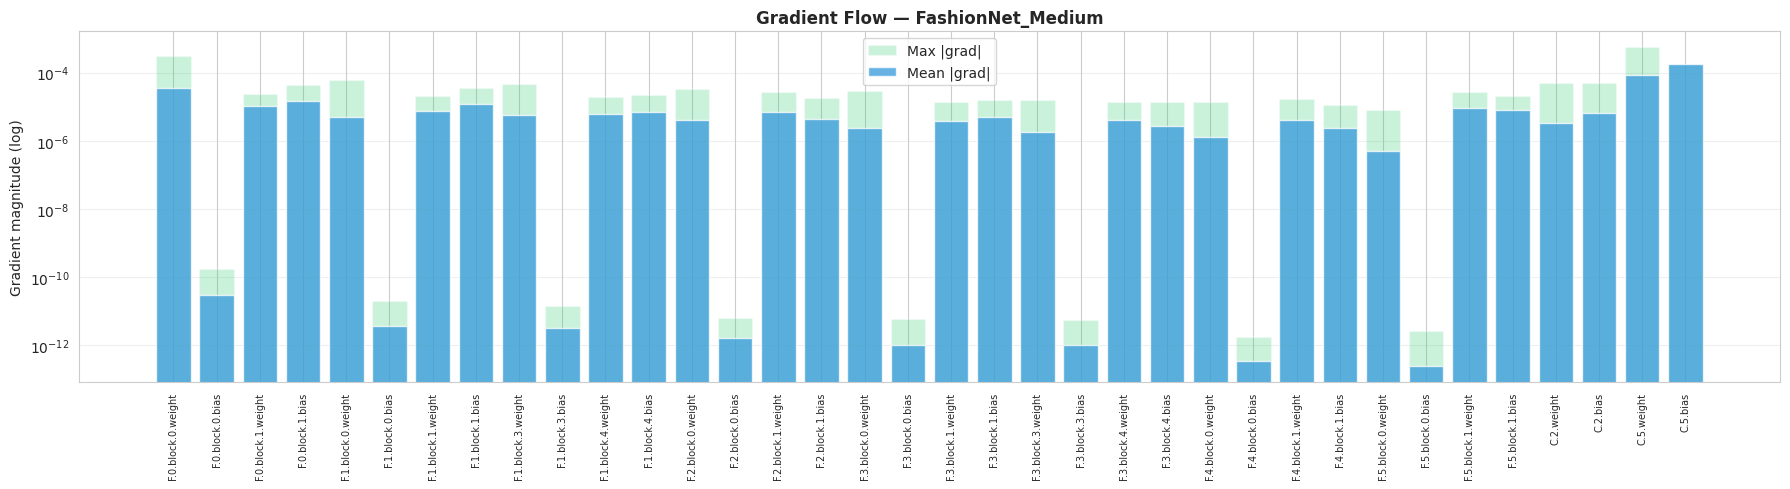

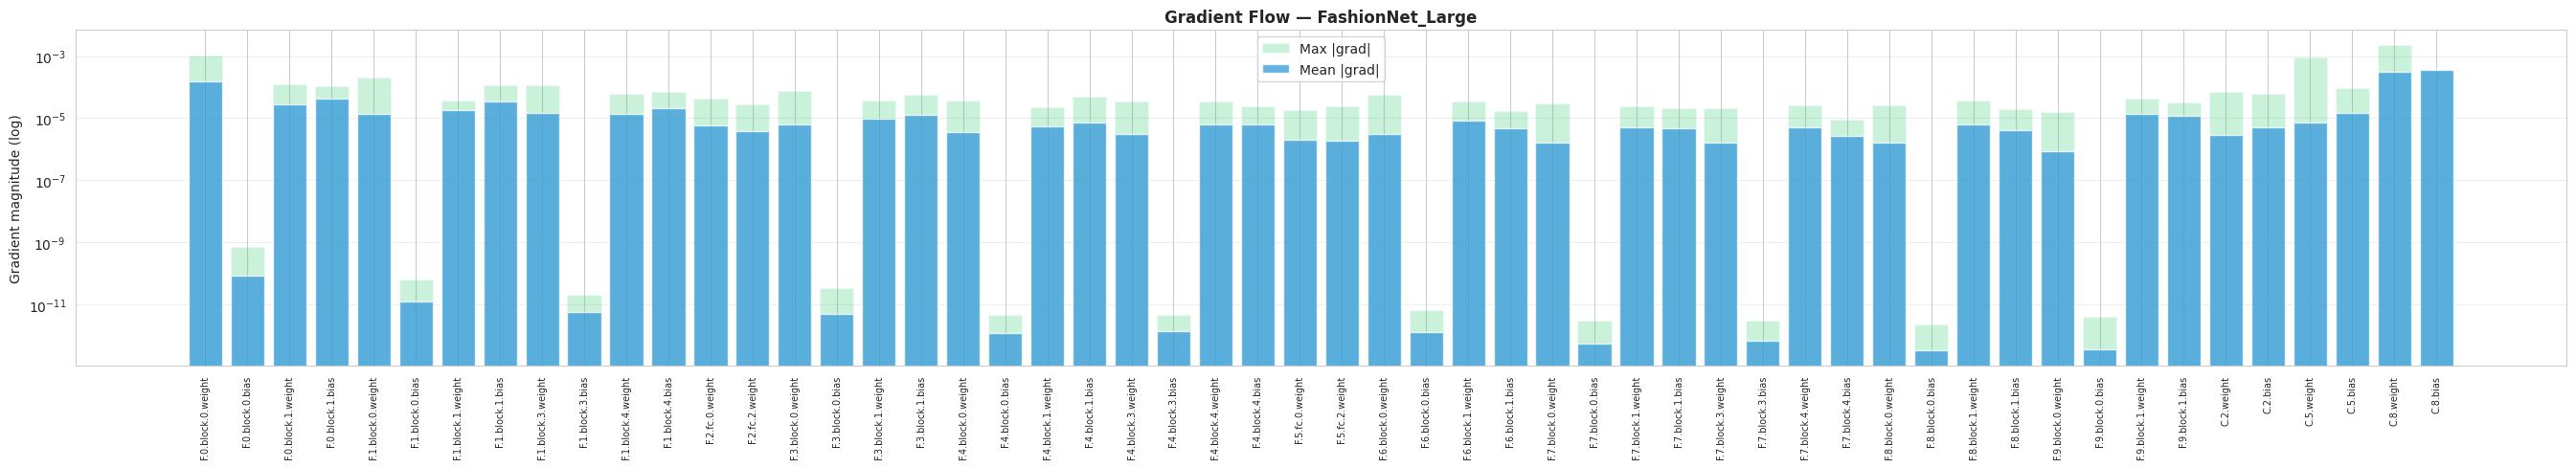

In [21]:
def plot_gradient_flow(trainers):
    for name, tr in trainers.items():
        tr.load_checkpoint(best=True)
        model = tr.model
        model.train()

        images, labels = next(iter(tr.train_loader))
        images, labels = images.to(device), labels.to(device)
        model.zero_grad()
        loss = tr.criterion(model(images), labels)
        loss.backward()

        layers, avg_grads, max_grads = [], [], []
        for n, p in model.named_parameters():
            if p.requires_grad and p.grad is not None:
                layers.append(n.replace('features.', 'F.').replace('classifier.', 'C.'))
                avg_grads.append(p.grad.abs().mean().item())
                max_grads.append(p.grad.abs().max().item())

        fig, ax = plt.subplots(figsize=(max(12, len(layers) * 0.5), 5))
        x = np.arange(len(layers))
        ax.bar(x, max_grads, alpha=0.25, color='#2ecc71', label='Max |grad|')
        ax.bar(x, avg_grads, alpha=0.75, color='#3498db', label='Mean |grad|')
        ax.set_xticks(x)
        ax.set_xticklabels(layers, rotation=90, fontsize=7)
        ax.set_yscale('log')
        ax.set_title(f'Gradient Flow — {name}', fontweight='bold')
        ax.set_ylabel('Gradient magnitude (log)')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

plot_gradient_flow(trainers)

## Задание 8. Дашборд для сравнения моделей

Интегрированный дашборд объединяет:
- Столбчатые диаграммы ключевых метрик
- Кривые обучения
- Радарную диаграмму
- Сводную таблицу

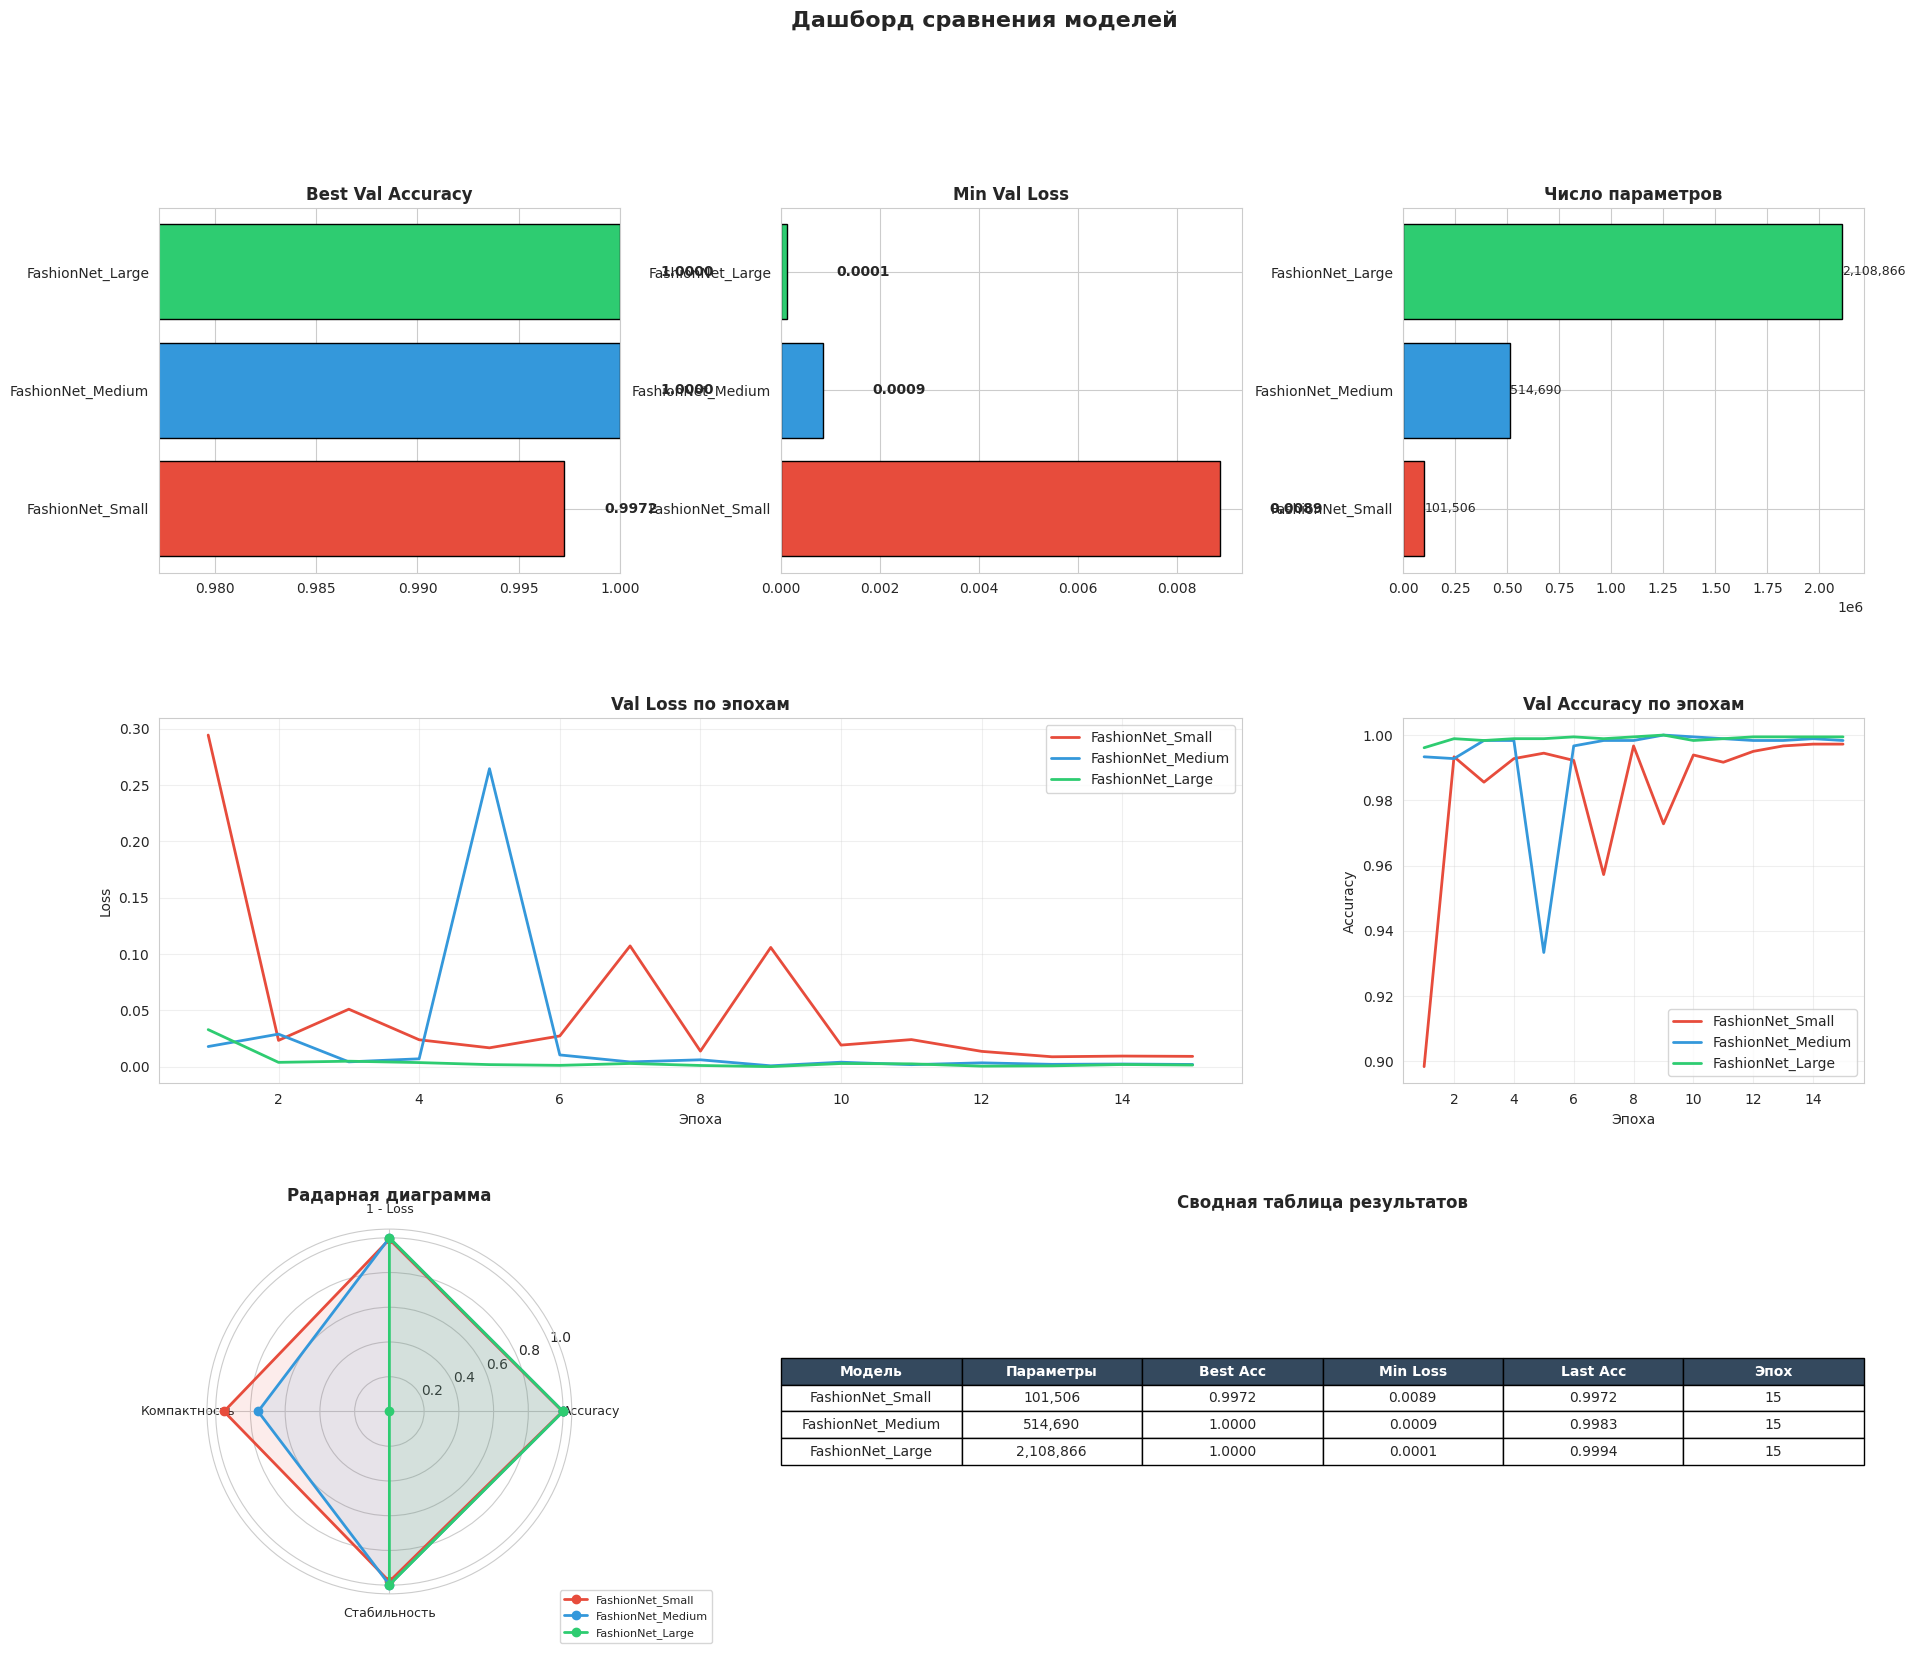

In [22]:
def comparison_dashboard(histories, trainers):
    model_names = list(histories.keys())
    colors = [COLORS[n] for n in model_names]
    n_models = len(model_names)

    fig = plt.figure(figsize=(22, 18))
    gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

    # ── 1. Best Val Accuracy ──
    ax1 = fig.add_subplot(gs[0, 0])
    best_accs = [max(histories[n]['val_acc']) for n in model_names]
    bars = ax1.barh(model_names, best_accs, color=colors, edgecolor='black')
    ax1.set_xlim(min(best_accs) - 0.02, 1.0)
    ax1.set_title('Best Val Accuracy', fontweight='bold')
    for i, v in enumerate(best_accs):
        ax1.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

    # ── 2. Min Val Loss ──
    ax2 = fig.add_subplot(gs[0, 1])
    min_losses = [min(histories[n]['val_loss']) for n in model_names]
    ax2.barh(model_names, min_losses, color=colors, edgecolor='black')
    ax2.set_title('Min Val Loss', fontweight='bold')
    for i, v in enumerate(min_losses):
        ax2.text(v + 0.001, i, f'{v:.4f}', va='center', fontweight='bold')

    # ── 3. Число параметров ──
    ax3 = fig.add_subplot(gs[0, 2])
    params = [count_params(trainers[n].model) for n in model_names]
    ax3.barh(model_names, params, color=colors, edgecolor='black')
    ax3.set_title('Число параметров', fontweight='bold')
    for i, v in enumerate(params):
        ax3.text(v + 500, i, f'{v:,}', va='center', fontsize=9)

    # ── 4. Val Loss curves ──
    ax4 = fig.add_subplot(gs[1, :2])
    for name in model_names:
        h = histories[name]
        ep = range(1, len(h['val_loss']) + 1)
        ax4.plot(ep, h['val_loss'], color=COLORS[name], linewidth=2, label=name)
    ax4.set_title('Val Loss по эпохам', fontweight='bold')
    ax4.set_xlabel('Эпоха'); ax4.set_ylabel('Loss')
    ax4.legend(); ax4.grid(True, alpha=0.3)

    # ── 5. Val Accuracy curves ──
    ax5 = fig.add_subplot(gs[1, 2])
    for name in model_names:
        h = histories[name]
        ep = range(1, len(h['val_acc']) + 1)
        ax5.plot(ep, h['val_acc'], color=COLORS[name], linewidth=2, label=name)
    ax5.set_title('Val Accuracy по эпохам', fontweight='bold')
    ax5.set_xlabel('Эпоха'); ax5.set_ylabel('Accuracy')
    ax5.legend(); ax5.grid(True, alpha=0.3)

    # ── 6. Радарная диаграмма ──
    ax6 = fig.add_subplot(gs[2, 0], polar=True)
    categories = ['Accuracy', '1 - Loss', 'Компактность', 'Стабильность']
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    max_params = max(params)
    for i, name in enumerate(model_names):
        h = histories[name]
        acc = max(h['val_acc'])
        loss_score = 1 - min(h['val_loss'])
        compact = 1 - count_params(trainers[name].model) / max_params
        # Стабильность: малый разброс val_acc в последних 5 эпохах
        last_accs = h['val_acc'][-5:]
        stability = 1 - np.std(last_accs) * 10 if len(last_accs) > 1 else 0.5
        stability = max(0, min(1, stability))

        vals = [acc, loss_score, compact, stability]
        vals += vals[:1]
        ax6.plot(angles, vals, 'o-', color=COLORS[name], linewidth=2, label=name)
        ax6.fill(angles, vals, alpha=0.1, color=COLORS[name])

    ax6.set_xticks(angles[:-1])
    ax6.set_xticklabels(categories, fontsize=9)
    ax6.set_title('Радарная диаграмма', fontweight='bold', pad=20)
    ax6.legend(loc='lower right', bbox_to_anchor=(1.4, -0.15), fontsize=8)

    # ── 7. Сводная таблица ──
    ax7 = fig.add_subplot(gs[2, 1:])
    ax7.axis('off')
    table_data = []
    for name in model_names:
        h = histories[name]
        table_data.append([
            name,
            f'{count_params(trainers[name].model):,}',
            f'{max(h["val_acc"]):.4f}',
            f'{min(h["val_loss"]):.4f}',
            f'{h["val_acc"][-1]:.4f}',
            f'{len(h["train_loss"])}',
        ])

    table = ax7.table(
        cellText=table_data,
        colLabels=['Модель', 'Параметры', 'Best Acc', 'Min Loss', 'Last Acc', 'Эпох'],
        loc='center', cellLoc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.6)
    for j in range(len(table_data[0])):
        table[0, j].set_facecolor('#34495e')
        table[0, j].set_text_props(color='white', fontweight='bold')
    ax7.set_title('Сводная таблица результатов', fontweight='bold', pad=15)

    plt.suptitle('Дашборд сравнения моделей', fontsize=16, fontweight='bold', y=0.99)
    plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()

comparison_dashboard(histories, trainers)

## Оценка лучшей модели на тестовой выборке

Лучшая модель: FashionNet_Medium

Test Accuracy: 0.9985

Classification Report (Test):
              precision    recall  f1-score   support

    Футболка       1.00      1.00      1.00      1000
     Ботинок       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



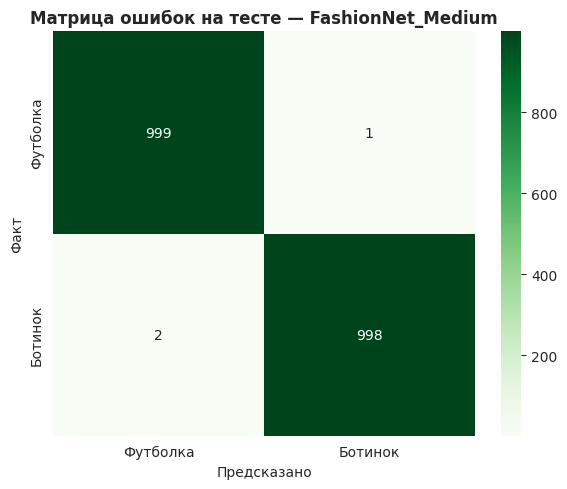

In [23]:
# Финальная оценка на тестовом наборе
best_name = max(histories, key=lambda n: max(histories[n]['val_acc']))
tr = trainers[best_name]
tr.load_checkpoint(best=True)
tr.model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = tr.model(images)
        probs = F.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

print(f'Лучшая модель: {best_name}')
print(f'\nTest Accuracy: {np.mean(np.array(all_preds) == np.array(all_labels)):.4f}')
print(f'\nClassification Report (Test):')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Матрица ошибок на тесте
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Матрица ошибок на тесте — {best_name}', fontweight='bold')
plt.xlabel('Предсказано'); plt.ylabel('Факт')
plt.tight_layout()
plt.show()

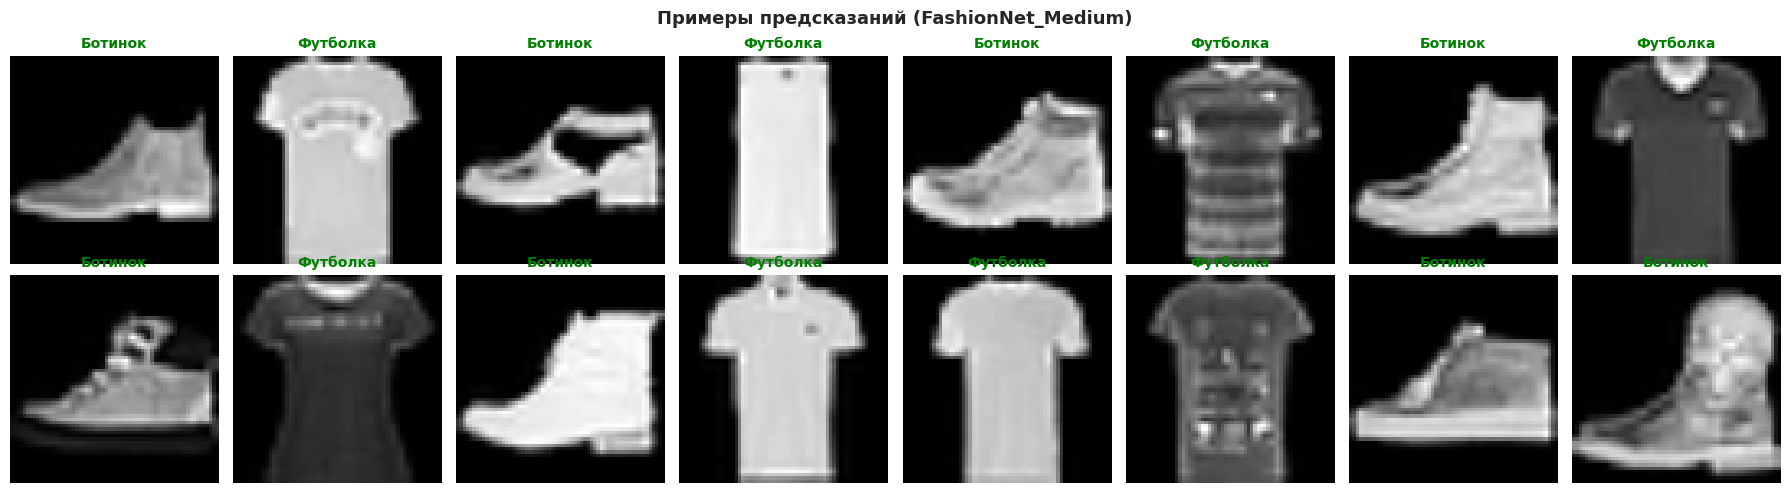

In [24]:
# Примеры предсказаний на тестовых данных
tr.model.eval()
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle(f'Примеры предсказаний ({best_name})', fontsize=13, fontweight='bold')

test_imgs_batch, test_lbls_batch = next(iter(test_loader))
with torch.no_grad():
    outputs = tr.model(test_imgs_batch.to(device))
    _, preds = outputs.max(1)
    preds = preds.cpu()

for i in range(16):
    r, c = divmod(i, 8)
    img = test_imgs_batch[i].squeeze().numpy() * 0.5 + 0.5
    true_lbl = CLASS_NAMES[test_lbls_batch[i]]
    pred_lbl = CLASS_NAMES[preds[i]]
    correct = preds[i] == test_lbls_batch[i]

    axes[r, c].imshow(img, cmap='gray')
    color = 'green' if correct else 'red'
    axes[r, c].set_title(f'{pred_lbl}', color=color, fontsize=10, fontweight='bold')
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

## Задание 9. Выводы

### 1. Конвейер обработки данных
Реализован двухступенчатый pipeline с использованием `torchvision.transforms`:
тренировочный конвейер включает **6 аугментаций** (horizontal flip, rotation, affine transform,
color jitter, Gaussian blur), валидационный — только resize и нормализацию.
Аугментация позволяет расширить обучающую выборку и снизить переобучение.

### 2. Кастомный DataLoader
Класс `FashionBinaryDataset` обеспечивает чтение grayscale-изображений из numpy-массива,
применение трансформаций и формирование пар `(image, label)`.
Данные разбиты на train (85%), val (15%) и test с сохранением баланса классов.
Размер батча — 64, изображения ресайзятся до 64×64.

### 3. Модульная архитектура CNN
Построены три модели на основе переиспользуемых блоков:
- **FashionNet_Small** — базовая архитектура из 3 свёрточных блоков (ConvBlock)
- **FashionNet_Medium** — 4 свёрточных блока с residual-соединениями (ResidualBlock)
- **FashionNet_Large** — 5 блоков с residual-соединениями и SE-attention (SEBlock)

### 4. Trainer с checkpointing
Класс `Trainer` реализует:
- Сохранение best/last чекпоинтов с полным состоянием модели и оптимизатора
- Early stopping с настраиваемым patience
- CosineAnnealingLR scheduler для плавного уменьшения learning rate
- CrossEntropyLoss для бинарной классификации

### 5. TensorBoard
В процессе обучения в TensorBoard записываются:
- Скаляры (Loss, Accuracy, Learning Rate) — для сравнения train/val динамики
- Граф модели (`add_graph`) — для визуализации архитектуры
- Гистограммы весов и градиентов (`add_histogram`) — для диагностики обучения

### 6. Визуализация
Построены кривые Loss, Accuracy и Learning Rate для всех трёх моделей.
Матрицы ошибок визуализированы для каждой модели, а также выведен детальный
classification report с precision, recall и F1-score.

### 7. Распределения градиентов и весов
Boxplot-диаграммы и gradient-flow показывают распределения весов и градиентов по слоям.
Модели с residual-соединениями (Medium, Large) демонстрируют более равномерный поток
градиентов, что подтверждает теоретическое преимущество skip-connections.

### 8. Дашборд сравнения
Интегрированный дашборд включает: столбчатые диаграммы метрик (Accuracy, Loss, параметры),
кривые обучения, радарную диаграмму и сводную таблицу результатов.

### Общие наблюдения
- Датасет Fashion-MNIST (T-shirt vs Ankle boot) хорошо сбалансирован (~6000 образцов на класс),
  что обеспечивает стабильное обучение без необходимости специальной балансировки.
- Все три модели достигают высокой точности, поскольку футболки и ботинки визуально
  сильно различаются. Однако более глубокие модели (Medium, Large) демонстрируют
  лучшую устойчивость к аугментациям и шуму.
- SE-блоки в Large-модели позволяют адаптивно перевзвешивать каналы, фокусируясь
  на наиболее информативных признаках.
- CosineAnnealingLR обеспечивает плавное снижение learning rate, что способствует
  стабильной сходимости в конце обучения.